# Linear Regression and Multiple Linear Regression 
## 1. Business Problem
The goal of this assignment is to analyze how different company expenditures impact profit. Specifically, we aim to assess if increasing spending in areas like R&D, Administration, and Marketing drives profitability, and to what extent each category contributes to overall profit.

## 2. Data Dictionary
**Dataset Link**: [50_Startups ](https://drive.google.com/file/d/13fdu7lupRF5EaVOlnlDuJ5VNDLkKiYTu/view)

| Feature Name       | DataType   | Description                                  |
|--------------------|------------|----------------------------------------------|
| **R_D_spent**      | Float      | Amount spent on Research and Development     |
| **Administration** | Float      | Administrative expenses                      |
| **Marketing_Spend**| Float      | Marketing expenditures                       |
| **State**          | Categorical| Location of company operations              |
| **Profit**         | Float      | Profit generated by the company             |

## 3. Data Pre-Processing

### 3.1 Data Inspection and Summary Statistics
- **Load the Dataset**: Import the dataset and review its basic structure, including column names, data types, and a few initial records.
- **Generate Summary Statistics**: Calculate key statistics (mean, median, min, max, standard deviation, etc.) to understand the primary characteristics of each column.

### 3.2 Data Cleaning 
- **Missing Values**: Verify and handle any missing or inconsistent values.
- **Duplicated Values**:Verify and handle the duplicated values in dataset

### 3.3 Outlier Treatment
- **Outlier Detection**: Identify outliers in `R_D_spent`, `Administration`, and `Marketing_Spend` using box plots and Z-scores.
- **Handling Outliers**: Treat outliers as necessary to ensure robust modeling.

## 4. Exploratory Data Analysis (EDA)
### 4.1 Summary Statistics
- **Summary Table**: Calculate the mean, median, variance, and standard deviation for each numerical feature to understand the data’s distribution.

### 4.2 Univariate Analysis
- **Numerical Data**: Visualize distributions with histograms and box plots to check for skewness and outliers.
- **Categorical Data**: Use bar charts to observe the distribution of categorical data.

### 4.3 Bivariate Analysis
- **Numerical-Numerical Relationships**: Create scatter plots to observe relationships between pairs of numerical variables.
- **Categorical-Numerical Relationships**: Use box and violin plots to analyze how categorical variables impact numerical distributions.
- **Correlation Analysis**: Generate a heatmap of the correlation matrix to identify potential relationships.

## 5. Model Building
### 5.1 Feature Engineering and Scaled Data 
- **Data Scaling**: Apply standardization to ensure all features are on a similar scale.
- **Model Selection**: Start with simple linear regression, then progress to multiple linear regression to capture more insights.

### 5.2 Multiple Linear Regression Model
- **Multicollinearity Check**: Assess multicollinearity by calculating the Variance Inflation Factor (VIF) for each feature.
- **Influence Analysis**: Use AvPlots and Influence Index Plots to identify any influential data points that could affect model accuracy.

### 5.3 Train-Test Split
- **Data Split**: Divide data into training and testing sets.
- **Performance Metrics**: Calculate R-squared and RMSE for both training and testing sets to evaluate the model’s performance.

### 5.4 Model Interpretation and Tuning
- **Interpretation**: Examine model coefficients to understand the impact of each feature on profit.
- **Model Tuning**: Explore advanced techniques such as polynomial and interaction terms, and consider using Ridge or Lasso regularization to improve model performance.


### Importing all the Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 3.1 Data Inspection and Summary Statistics

In [2]:
df = pd.read_csv("50_Startups.csv")

In [3]:
df.head()

,R_D_spent,Administration,Marketing_Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


### Observation:

- Upon analyzing the dataset, it is evident that it includes both independent and dependent variables.
- The independent variables consist of continuous data, making regression an appropriate approach for solving this problem.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R_D_spent        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing_Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [5]:
df.describe()

,R_D_spent,Administration,Marketing_Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


### 3.2 Data Cleaning and Feature Engineering

In [6]:
df.isnull().sum()

R_D_spent          0
Administration     0
Marketing_Spend    0
State              0
Profit             0
dtype: int64

In [7]:
print(df.duplicated().sum())

0


### 3.3 Outlier Treatment


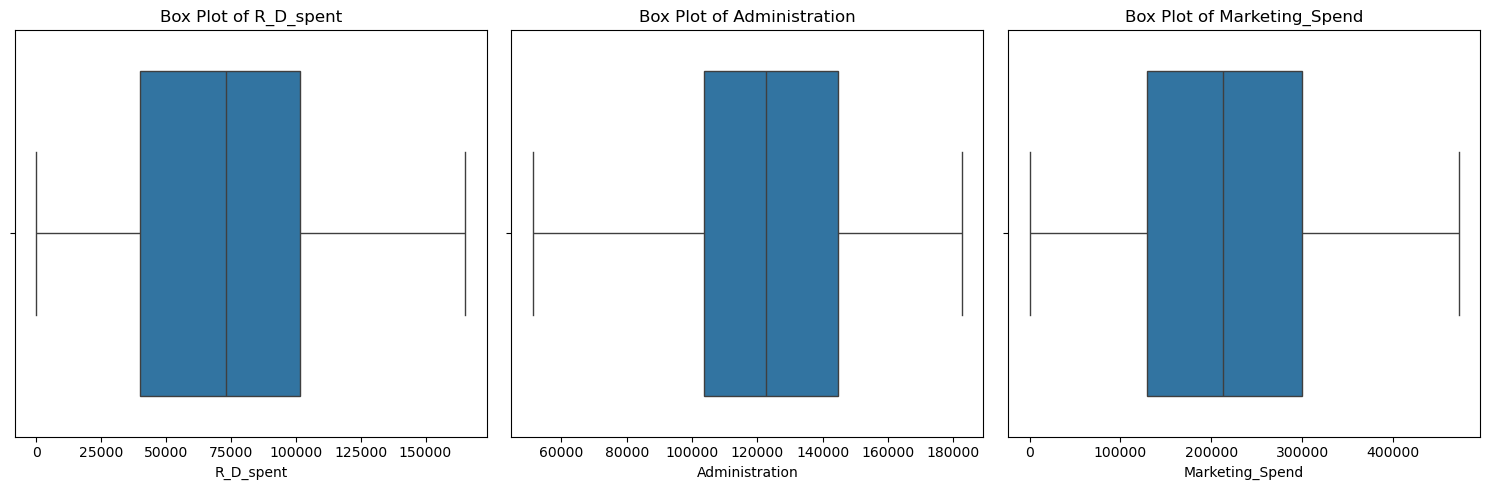

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['R_D_spent', 'Administration', 'Marketing_Spend']

plt.figure(figsize=(15, 5))  


for i, col in enumerate(cols, start=1):
    plt.subplot(1, 3, i)  
    sns.boxplot(data=df, x=col)  
    plt.title(f'Box Plot of {col}')  


plt.tight_layout()  
plt.show()


- There is no outlier in the dataset

## 4. Exploratory Data Analysis (EDA)


### 4.2 Univariate Analysis
- **Numerical Data**: Visualize distributions with histograms and box plots to check for skewness and outliers.
- **Categorical Data**: Use bar charts to observe the distribution of categorical data.

### 4.3 Bivariate Analysis
- **Numerical-Numerical Relationships**: Create scatter plots to observe relationships between pairs of numerical variables.
- **Categorical-Numerical Relationships**: Use box and violin plots to analyze how categorical variables impact numerical distributions.
- **Correlation Analysis**: Generate a heatmap of the correlation matrix to identify potential relationships.

In [9]:
df.head()

,R_D_spent,Administration,Marketing_Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [10]:
df.columns

Index(['R_D_spent', 'Administration', 'Marketing_Spend', 'State', 'Profit'], dtype='object')

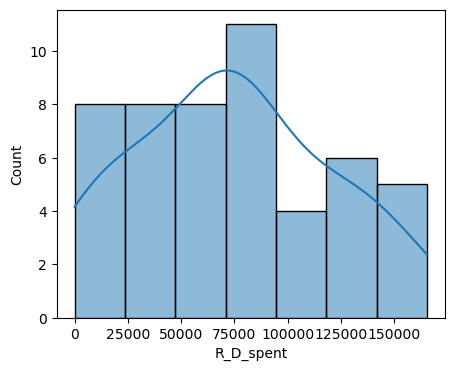

In [11]:
# Univariate Analysis

plt.figure(figsize=(5,4))
sns.histplot(data=df,x = 'R_D_spent',kde=True)
plt.show()


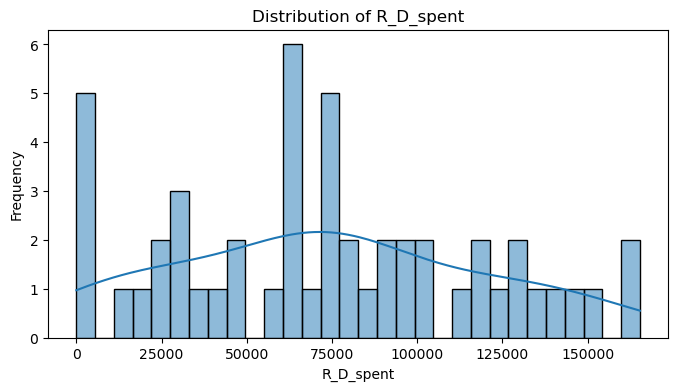

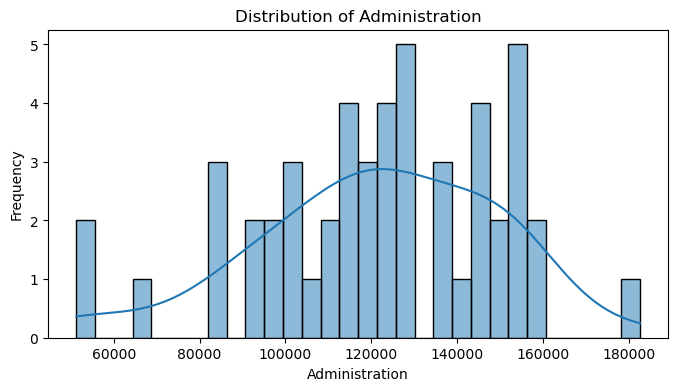

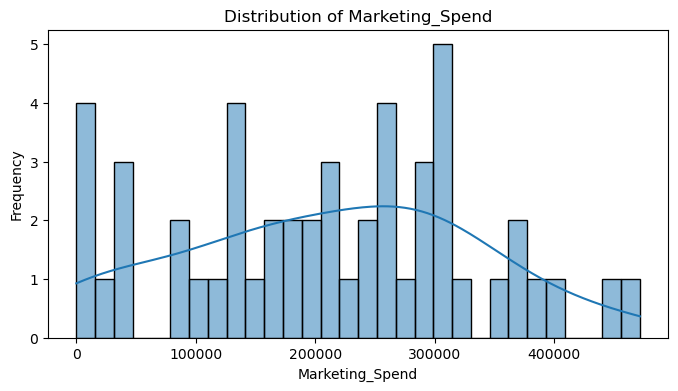

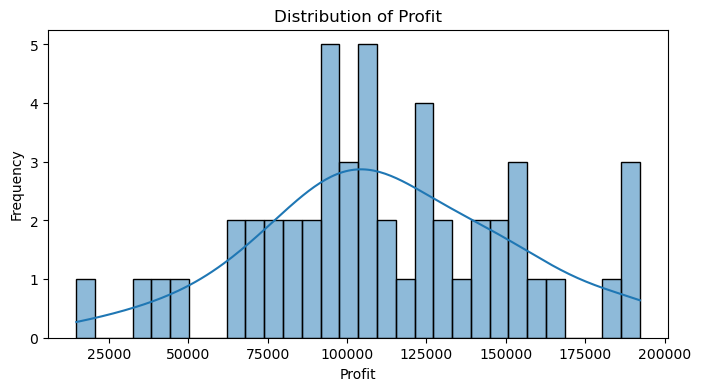

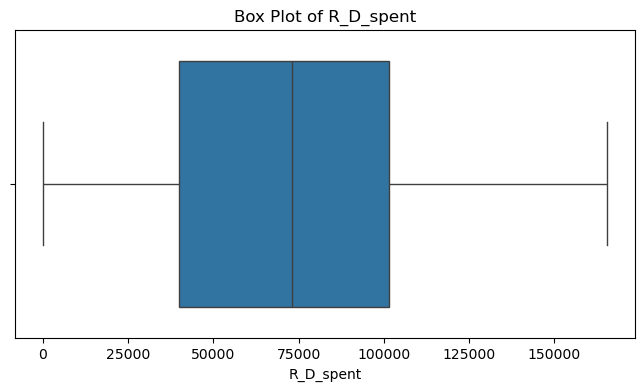

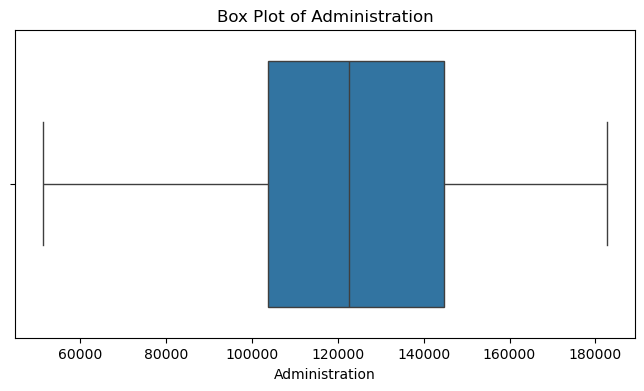

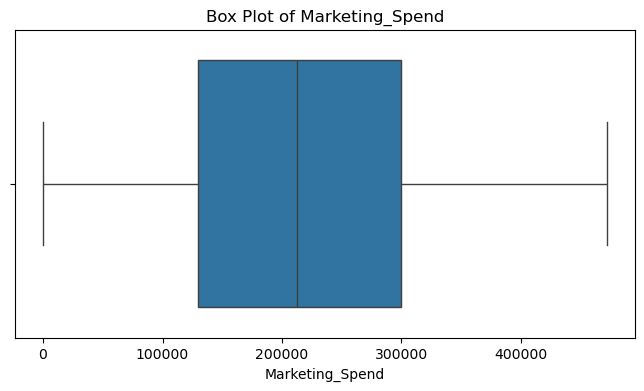

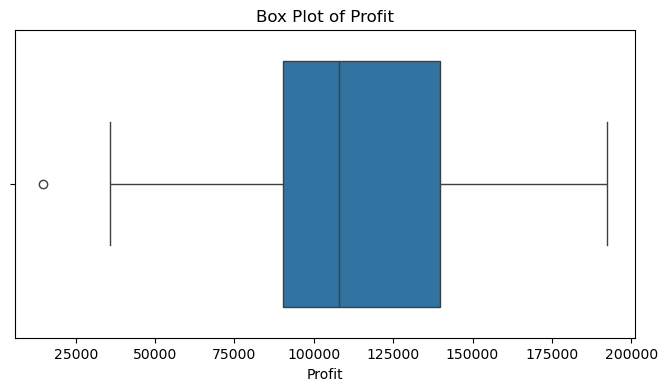

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is the DataFrame

# Univariate Analysis: Numerical Data
numerical_cols = ['R_D_spent', 'Administration', 'Marketing_Spend', 'Profit']

# Histograms for numerical data
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Box plots for numerical data
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.show()




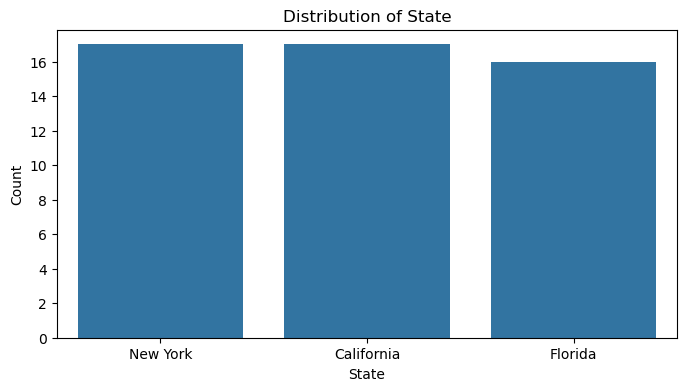

In [13]:
# Univariate Analysis: Categorical Data
categorical_col = 'State'

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x=categorical_col)
plt.title(f'Distribution of {categorical_col}')
plt.xlabel(categorical_col)
plt.ylabel('Count')
plt.show()

In [14]:
# Bivariate Analysis: Numerical-Numerical Relationships
numerical_cols_pairs = [('R_D_spent', 'Profit'), ('Marketing_Spend', 'Profit'), ('Administration', 'Profit')]

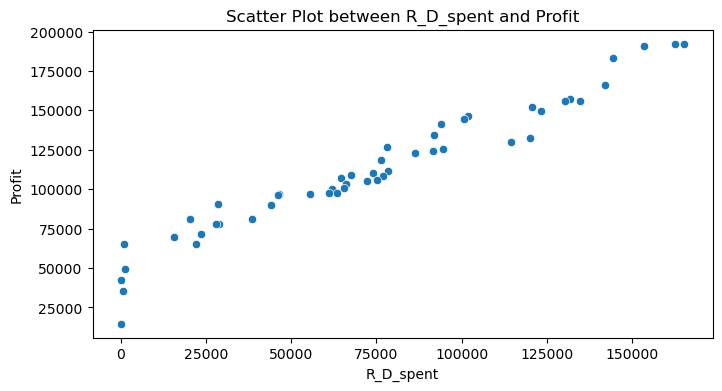

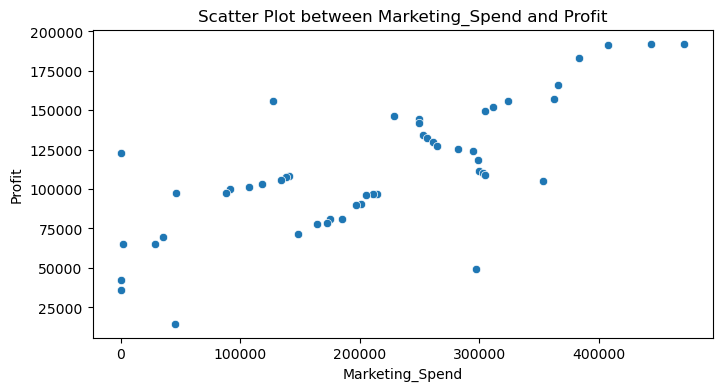

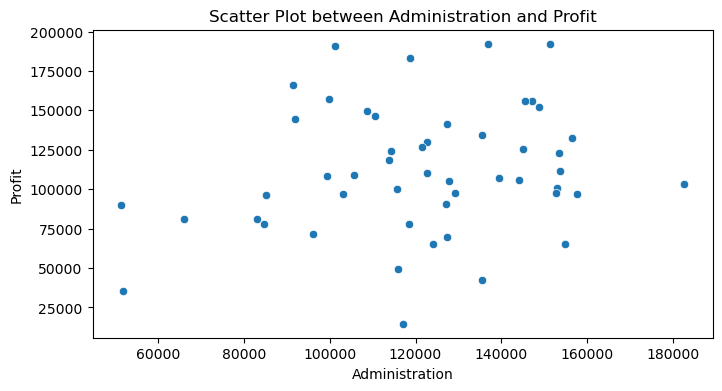

In [15]:
for col1, col2 in numerical_cols_pairs:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(data=df, x=col1, y=col2)
    plt.title(f'Scatter Plot between {col1} and {col2}')
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.show()


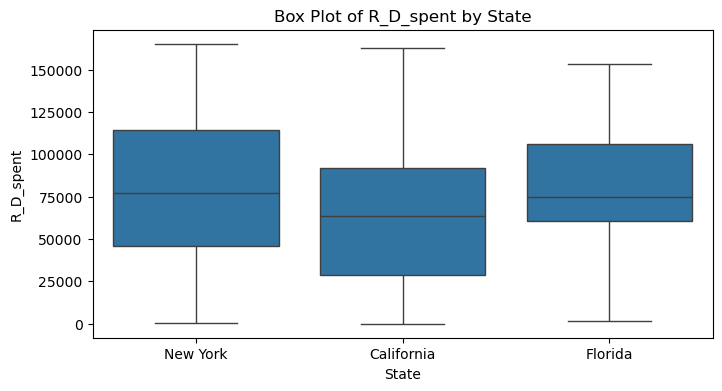

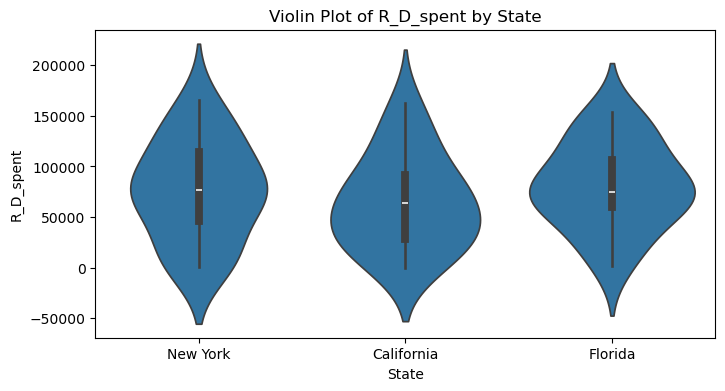

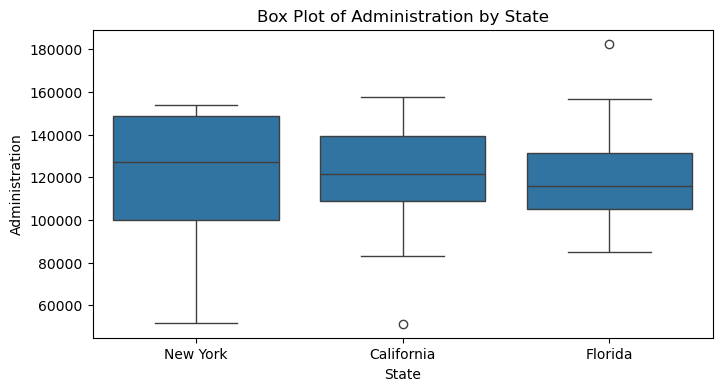

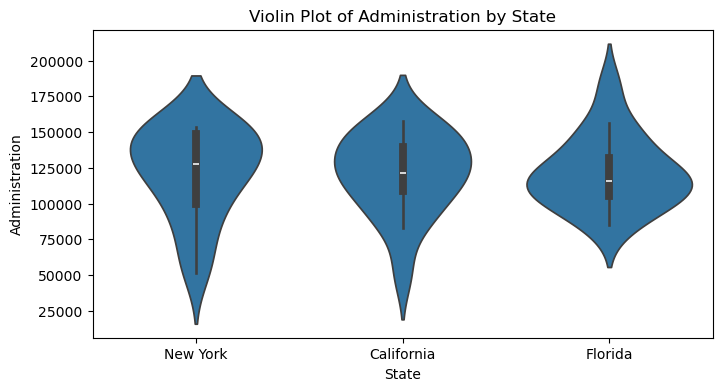

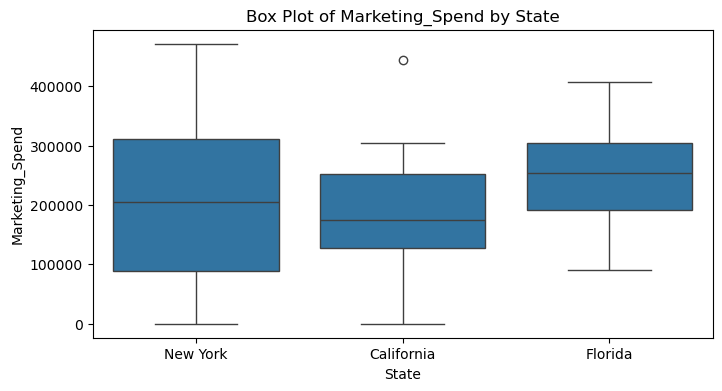

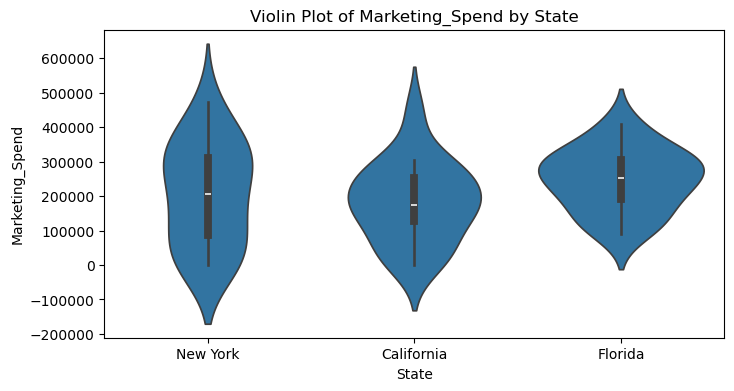

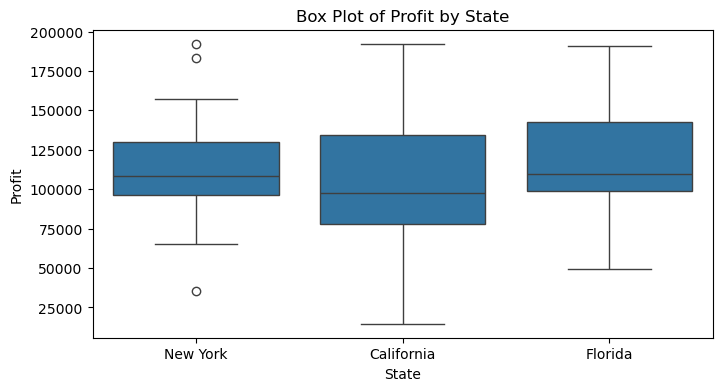

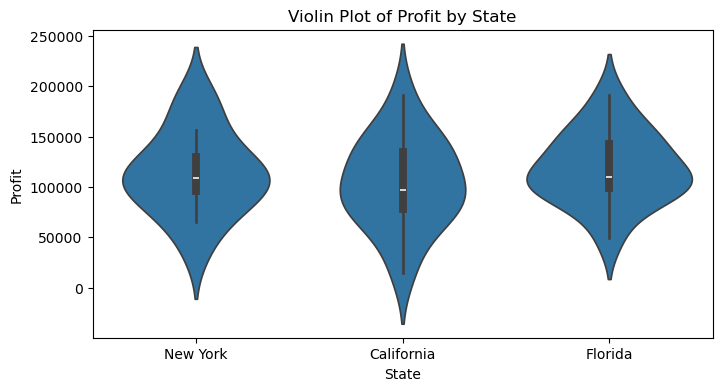

In [16]:

# Bivariate Analysis: Categorical-Numerical Relationships
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='State', y=col)
    plt.title(f'Box Plot of {col} by State')
    plt.xlabel('State')
    plt.ylabel(col)
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.violinplot(data=df, x='State', y=col)
    plt.title(f'Violin Plot of {col} by State')
    plt.xlabel('State')
    plt.ylabel(col)
    plt.show()



In [17]:
# Correlation Analysis: Heatmap
plt.figure(figsize=(8, 4))
correlation_matrix = df.corr()  # Compute correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

ValueError: could not convert string to float: 'New York'

<Figure size 800x400 with 0 Axes>

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode categorical columns and assign back to the DataFrame
df['State'] = label_encoder.fit_transform(df['State'])




### 5.3 Train-Test Split




In [ ]:
# from sklearn.model_selection import StandartScalar
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split




In [ ]:
x = df.drop("Profit",axis = 1)
y = df[['Profit']]

### Split the Dataset

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=80)


In [ ]:
x_train.head()

In [ ]:
x_test.head()

In [ ]:
y_train.head()

In [ ]:
y_test.head()

### Train the Model

In [ ]:
lr_regression = LinearRegression()
lr_regression.fit(x_train,y_train) 

In [ ]:
print("Intercept:", lr_regression.intercept_)
print("Coefficients:", lr_regression.coef_)


### Make Predictions

In [ ]:
y_pred = lr_regression.predict(x_test)

# Display predictions
print("Predicted values:\n", y_pred[:5])


In [ ]:
# R² Score
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Square Error (RMSE):", rmse)


# Model Performance

### R² Score: 0.8988
The model explains **89.88% of the variability** in the target variable. This indicates a **good fit** and suggests that the predictors are capturing the majority of the relationship with the target variable.  

### Root Mean Square Error (RMSE): 8084.53
On average, the model’s predictions deviate from the actual values by approximately **8084 units**.  
- The magnitude of RMSE should be compared with the **range of the target variable**.  
- If the range is large (e.g., target values vary between tens or hundreds of thousands), this error may be **acceptable**.  
- If the range of the target variable is narrow, the error could indicate **room for improvement** in the model.

### Mean Squared Error (MSE): 65359553.28
The squared error metric highlights the model's **sensitivity to larger errors**.  
- While this metric is less intuitive than RMSE, it **complements** the understanding of prediction quality.


### 5.4 Model Interpretation and Tuning

**Linearity**

In [ ]:
plt.scatter(y_pred,y_test-y_pred)
plt.axhline(y=0,color ='r',linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residual')
plt.show()

# Residual Plot Analysis

## Observations:

1. **Random Scatter**:
   - The residuals are scattered above and below the red dashed line (residual = 0), which is a good indication that the model doesn't have a systematic bias.  

2. **Presence of Patterns**:
   - There seems to be a slight trend where residuals increase or decrease with predicted values, especially at the lower and upper ends of the plot.  
   - This suggests **heteroscedasticity**, where the error variance changes across the range of predicted values.

3. **Outliers**:
   - A few residuals are significantly far from the zero line (e.g., above 10,000 or below -10,000).  
   - These outliers could indicate areas where the model struggles to make accurate predictions.

4. **Range of Residuals**:
   - Residuals range approximately between **-12,000 to 15,000**, indicating some significant errors in predictions.



### Normality of Residuals

In [ ]:
sns.histplot(y_test - y_pred, kde=True)
plt.title("Residuals Distribution")
plt.show()


# Residuals Distribution Analysis

## Observations:

1. **Shape of Distribution**:
   - The histogram shows the residuals are distributed with a peak around **0**.
   - However, the distribution is not perfectly symmetric, suggesting potential deviations from normality.

2. **Spread of Residuals**:
   - Residuals range from approximately **-10,000 to 15,000**.
   - The higher density of residuals near **0** indicates that the model performs well for most predictions.

3. **Presence of Skewness**:
   - A slightly uneven spread on the left and right suggests some **skewness** in the residual distribution. This could indicate systematic errors in certain ranges.

4. **Density Curve**:
   - The overlaying curve highlights that the residuals loosely follow a normal distribution, but there are deviations in the tails.



### Multicollinearity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
# Add a constant for VIF calculation
X_with_const = sm.add_constant(x)

# Calculate VIF
vif = pd.DataFrame()
vif['Features'] = x.columns
vif['VIF'] = [variance_inflation_factor(X_with_const.values, i) for i in range(1, X_with_const.shape[1])]

print(vif)


- Ensure all relevant features are included to minimize unexplained variability.

